In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("TvMarketing.csv")
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


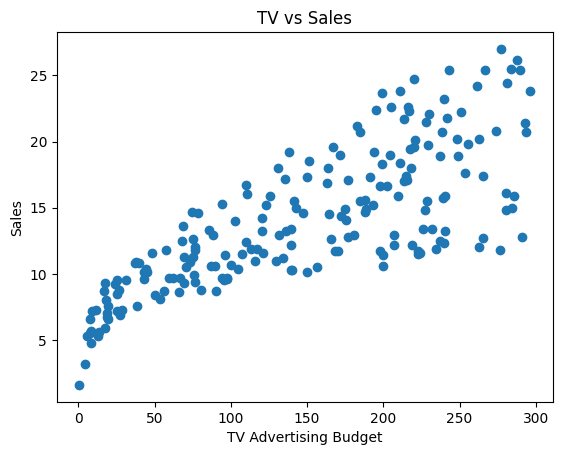

In [ ]:
plt.figure()
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()


In [ ]:
X = df[["TV"]]      # Feature
y = df["Sales"]     # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (160, 1)
X_test shape: (40, 1)
y_train shape: (160,)
y_test shape: (40,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
b0 = model.intercept_
b1 = model.coef_[0]

print("Intercept (b0):", b0)
print("Slope (b1):", b1)


Intercept (b0): 7.119638430592953
Slope (b1): 0.046529733705443346


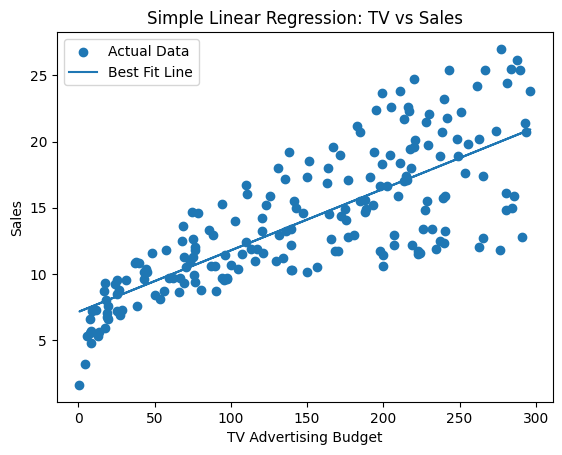

In [ ]:
plt.figure()
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Best Fit Line")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Simple Linear Regression: TV vs Sales")
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,14.717944
1,22.4,16.211548
2,21.4,20.748197
3,7.3,7.664036
4,24.7,17.370139
5,12.6,10.614021
6,22.3,17.207285
7,8.4,9.446125
8,11.5,17.467851
9,14.9,15.266995


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)


RMSE: 3.194472431998898
R² Score: 0.6766954295627076


Experiment 2

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df2 = pd.read_csv("vehicle_co2_dataset.csv")
df2.head()


,vehicle_id,make,fuel_type,model_year,engine_cc,vehicle_weight,cylinders,annual_mileage_km,vehicle_age,co2_g_km,...,co2_proxy_51,co2_proxy_52,co2_proxy_53,co2_proxy_54,co2_proxy_55,co2_proxy_56,co2_proxy_57,co2_proxy_58,co2_proxy_59,co2_proxy_60
0,1,Ford,Petrol,2015,1723.557940,1584.733203,4,10529.056031,10,156.791111,...,149.661615,162.401641,153.646051,162.368301,157.700825,152.412577,162.779976,159.588916,163.360784,158.361936
1,2,Mercedes,Petrol,2010,1425.111578,1622.249986,4,15779.243800,15,143.193198,...,136.682017,148.317148,140.320897,148.286699,144.024016,139.194398,148.662671,145.748359,149.193108,144.627791
2,3,Audi,Hybrid,2011,1244.080888,1473.990569,4,14129.167461,14,123.553651,...,117.935506,127.974830,121.075298,127.948557,124.270519,120.103304,128.272963,125.758361,128.730648,124.791483
3,4,BMW,Petrol,2009,2177.834260,1831.274096,4,9290.136453,16,183.750695,...,175.395312,190.325932,180.064854,190.286860,184.816830,178.619290,190.769320,187.029570,191.449996,185.591616
4,5,Toyota,Petrol,2007,1848.899157,1732.637242,4,25519.247019,18,188.039024,...,179.488644,194.767712,184.267163,194.727728,189.130040,182.787863,195.221448,191.394420,195.918009,189.922908


In [ ]:
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 431 entries, vehicle_id to co2_proxy_60
dtypes: float64(394), int64(34), object(3)
memory usage: 6.6+ MB


,vehicle_id,model_year,engine_cc,vehicle_weight,cylinders,annual_mileage_km,vehicle_age,co2_g_km,ambient_temp_avg_1,altitude_avg_1,...,co2_proxy_51,co2_proxy_52,co2_proxy_53,co2_proxy_54,co2_proxy_55,co2_proxy_56,co2_proxy_57,co2_proxy_58,co2_proxy_59,co2_proxy_60
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2014.635500,1667.830535,1570.320285,4.121000,14290.749803,10.364500,155.302338,22.057640,293.450465,...,148.240539,160.859595,152.187141,160.826571,156.203414,150.965380,161.234337,158.073577,161.809630,156.858247
std,577.494589,5.225638,663.108664,279.587219,1.682193,6076.046398,5.225638,44.433574,6.739598,195.530386,...,42.413122,46.023561,43.542284,46.014113,44.691381,43.192726,46.130779,45.226453,46.295376,44.878735
min,1.000000,2006.000000,0.000000,900.000000,0.000000,3752.210548,2.000000,50.000000,-0.398324,-397.956014,...,47.726435,51.789174,48.997054,51.778542,50.290104,48.603705,51.909823,50.892208,52.095040,50.500929
25%,500.750000,2010.000000,1356.690263,1414.958784,4.000000,9897.995496,6.000000,133.109010,17.541240,160.019226,...,127.056370,137.872113,130.438987,137.843808,133.881319,129.391821,138.193303,135.484228,138.686384,134.442574
50%,1000.500000,2015.000000,1758.384459,1590.073026,4.000000,13165.495503,10.000000,159.205305,21.968745,294.499655,...,151.966033,164.902224,156.011819,164.868370,160.129027,154.759353,165.286384,162.046189,165.876135,160.800317
75%,1500.250000,2019.000000,2096.715053,1758.441768,4.000000,17351.340037,15.000000,184.602008,26.603648,427.459971,...,176.207914,191.207709,180.899091,191.168455,185.673083,179.446830,191.653151,187.896074,192.336980,186.451458
max,2000.000000,2023.000000,3599.733390,2423.872123,8.000000,47203.114330,19.000000,292.849725,44.512141,963.537411,...,279.533467,303.328905,286.975475,303.266633,294.548861,284.671631,304.035547,298.075380,305.120363,295.783664


In [ ]:
VOLUME_COL = "engine_cc"
WEIGHT_COL = "vehicle_weight"
CO2_COL = "co2_g_km"

In [ ]:
corr_matrix = df2[[VOLUME_COL, WEIGHT_COL, CO2_COL]].corr()
corr_matrix

,engine_cc,vehicle_weight,co2_g_km
engine_cc,1.000000,0.905403,0.909879
vehicle_weight,0.905403,1.000000,0.869412
co2_g_km,0.909879,0.869412,1.000000


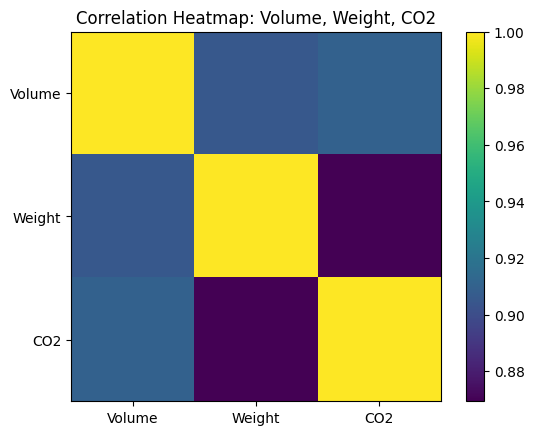

In [ ]:
plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(3), ["Volume", "Weight", "CO2"])
plt.yticks(range(3), ["Volume", "Weight", "CO2"])
plt.title("Correlation Heatmap: Volume, Weight, CO2")
plt.show()

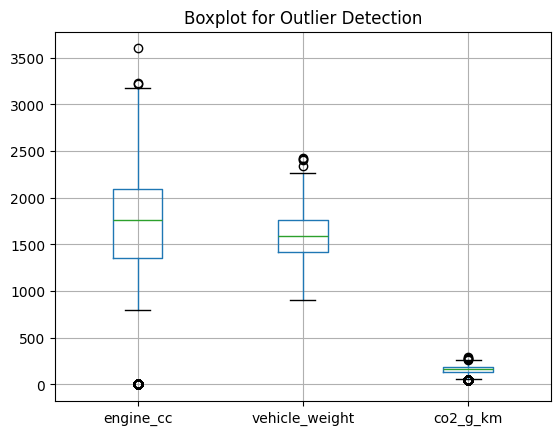

In [ ]:
plt.figure()
df2[[VOLUME_COL, WEIGHT_COL, CO2_COL]].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

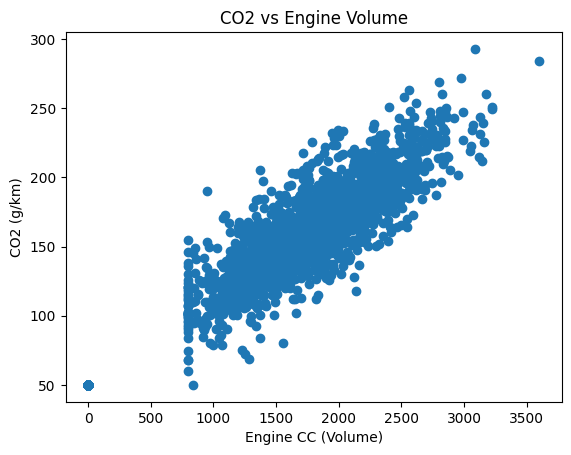

In [ ]:
plt.figure()
plt.scatter(df2[VOLUME_COL], df2[CO2_COL])
plt.xlabel("Engine CC (Volume)")
plt.ylabel("CO2 (g/km)")
plt.title("CO2 vs Engine Volume")
plt.show()

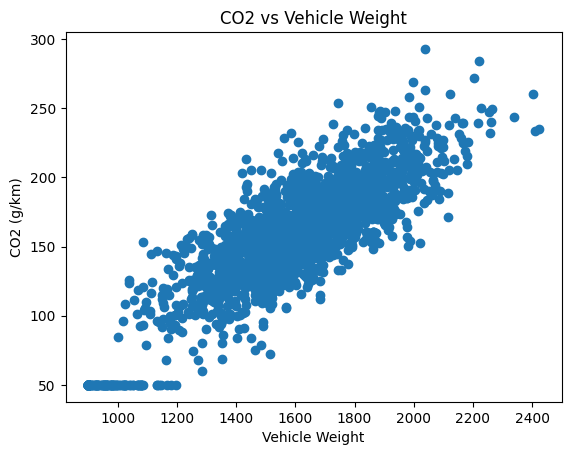

In [ ]:
plt.figure()
plt.scatter(df2[WEIGHT_COL], df2[CO2_COL])
plt.xlabel("Vehicle Weight")
plt.ylabel("CO2 (g/km)")
plt.title("CO2 vs Vehicle Weight")
plt.show()

In [ ]:
X = df2[[VOLUME_COL, WEIGHT_COL]]
y = df2[CO2_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 2)
X_test shape: (400, 2)
y_train shape: (1600,)
y_test shape: (400,)


In [ ]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept (b0):", model2.intercept_)
print("Coefficient for Volume (engine_cc):", model2.coef_[0])
print("Coefficient for Weight (vehicle_weight):", model2.coef_[1])

Intercept (b0): 19.3961353455511
Coefficient for Volume (engine_cc): 0.04656695435734196
Coefficient for Weight (vehicle_weight): 0.03724529674036983


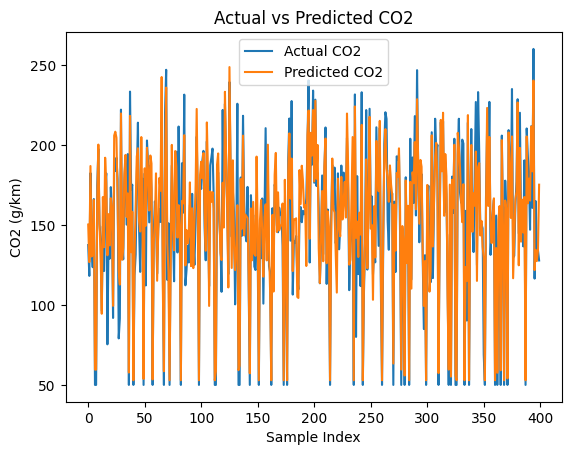

In [ ]:
y_pred2 = model2.predict(X_test)
plt.figure()
plt.plot(range(len(y_test)), y_test.values, label="Actual CO2")
plt.plot(range(len(y_pred2)), y_pred2, label="Predicted CO2")
plt.title("Actual vs Predicted CO2")
plt.xlabel("Sample Index")
plt.ylabel("CO2 (g/km)")
plt.legend()
plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 13.043662655343564
Mean Squared Error (MSE): 300.41437526122735
Root Mean Squared Error (RMSE): 17.332465931344778


Experiment 3

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

In [ ]:
df3 = pd.read_csv("advertising.csv")
df3.head()
df3.info()
df3.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [ ]:
df3.isnull().sum()
df3 = df3.fillna(df3.mean(numeric_only=True))

In [ ]:
df3.columns
df3_clean = df3.select_dtypes(include=[np.number])
df3_clean.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


In [ ]:
X = df3_clean.drop(columns=["Clicked on Ad"])
y = df3_clean["Clicked on Ad"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

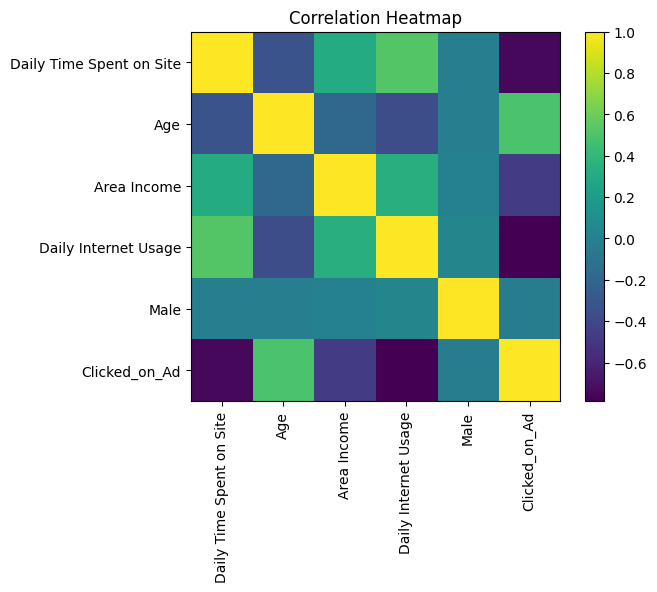

In [ ]:
corr_matrix = pd.DataFrame(X_scaled, columns=X.columns).assign(Clicked_on_Ad=y).corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 5)
X_test shape: (200, 5)
y_train shape: (800,)
y_test shape: (200,)


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
print("Intercept:", log_model.intercept_)
print("Coefficients:", log_model.coef_)

Intercept: [1.47571247]
Coefficients: [[-2.52553311  1.25056071 -1.63704805 -2.70402918 -0.35862744]]


In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_model, X_scaled, y, cv=kfold, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.96  0.98  0.985 0.96  0.97 ]
Mean CV Accuracy: 0.9709999999999999


In [ ]:
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



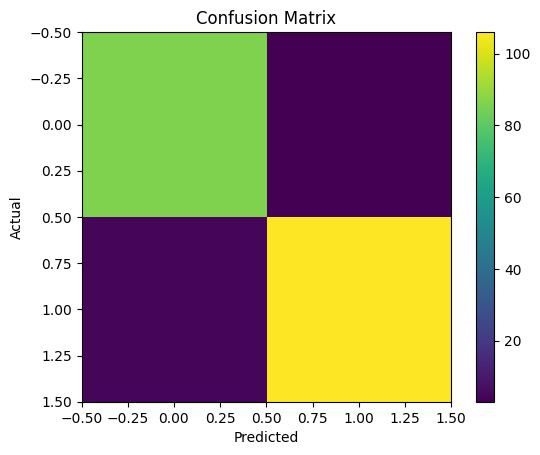

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


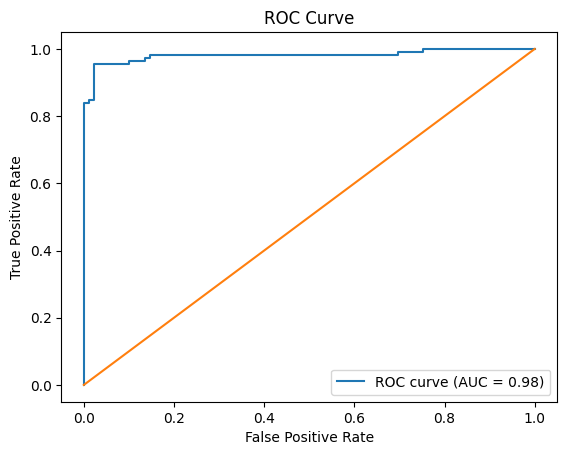

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

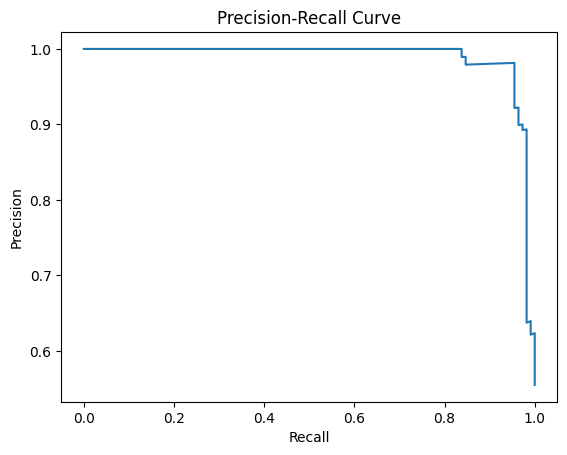

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


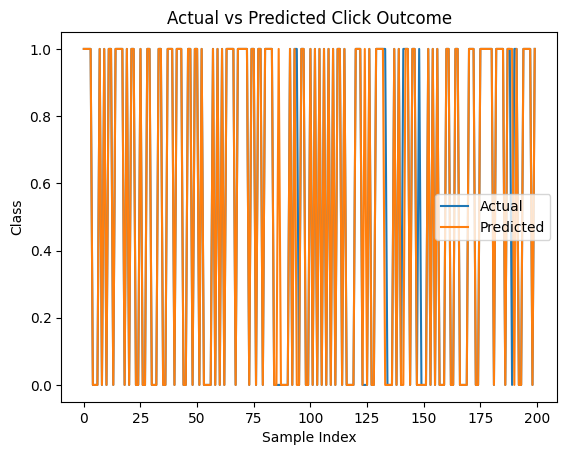

In [ ]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted Click Outcome")
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.legend()
plt.show()
